# TokaMark real-shot feasibility check
# Shot: 11766
# Goal: inspect one real shot and build a first failure-memory fingerprint

In [1]:
OUTER_ZIP = "data.part1.zip"
INNER_ZIP = "stage_upload/11766.zarr.zip"
EXTRACT_DIR = "tmp_11766"

In [2]:
import shutil
import zipfile, io,os
if os.path.exists(EXTRACT_DIR):
    shutil.rmtree(EXTRACT_DIR)
os.makedirs(EXTRACT_DIR, exist_ok=True)

with zipfile.ZipFile(OUTER_ZIP, "r") as outer:
    inner_bytes = outer.read(INNER_ZIP)

with zipfile.ZipFile(io.BytesIO(inner_bytes), "r") as inner:
    inner.extractall(EXTRACT_DIR)

print("Extracted one shot to:", EXTRACT_DIR)

Extracted one shot to: tmp_11766


In [3]:
base = os.path.join(EXTRACT_DIR, "11766.zarr")
print(os.listdir(base))

['.zgroup', '.zmetadata', 'equilibrium', 'gas_injection', 'interferometer', 'magnetics', 'pf_active', 'pulse_schedule', 'spectrometer_visible', 'summary']


In [4]:
def list_group(path, max_items=30):
    items = []
    for root, dirs, files in os.walk(path):
        for d in dirs:
            items.append(os.path.join(root, d))
        for f in files:
            items.append(os.path.join(root, f))
    for item in items[:max_items]:
        print(item)

### Signal structure check

We first verify that the real shot contains the signal groups needed for fingerprint construction: interferometer, summary, and magnetics.

In [5]:
list_group(os.path.join(base, "interferometer"), max_items=50)
print("-" * 60)
list_group(os.path.join(base, "summary"), max_items=50)
print("-" * 60)
list_group(os.path.join(base, "magnetics"), max_items=100)

tmp_11766\11766.zarr\interferometer\n_e_line
tmp_11766\11766.zarr\interferometer\time
tmp_11766\11766.zarr\interferometer\.zattrs
tmp_11766\11766.zarr\interferometer\.zgroup
tmp_11766\11766.zarr\interferometer\n_e_line\.zarray
tmp_11766\11766.zarr\interferometer\n_e_line\.zattrs
tmp_11766\11766.zarr\interferometer\n_e_line\0
tmp_11766\11766.zarr\interferometer\time\.zarray
tmp_11766\11766.zarr\interferometer\time\.zattrs
tmp_11766\11766.zarr\interferometer\time\0
------------------------------------------------------------
tmp_11766\11766.zarr\summary\greenwald_density
tmp_11766\11766.zarr\summary\ip
tmp_11766\11766.zarr\summary\line_average_n_e
tmp_11766\11766.zarr\summary\power_radiated
tmp_11766\11766.zarr\summary\time
tmp_11766\11766.zarr\summary\.zattrs
tmp_11766\11766.zarr\summary\.zgroup
tmp_11766\11766.zarr\summary\greenwald_density\.zarray
tmp_11766\11766.zarr\summary\greenwald_density\.zattrs
tmp_11766\11766.zarr\summary\greenwald_density\0
tmp_11766\11766.zarr\summary\ip\.za

In [6]:
%pip install zarr numcodecs

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import zarr
import os

store_path = os.path.join(EXTRACT_DIR, "11766.zarr")
root = zarr.open(store_path, mode="r")
print(root.tree())

/
├── equilibrium
│   ├── beta_normal (83,) float64
│   ├── beta_pol (83,) float64
│   ├── beta_tor (83,) float64
│   ├── bphi_rmag (83,) float64
│   ├── bvac_rmag (83,) float64
│   ├── da_rating (83,) float64
│   ├── elongation (83,) float64
│   ├── elongation_axis (83,) float64
│   ├── ip_rating (83,) float64
│   ├── j_tor (65, 65, 83) float64
│   ├── lcfs_r (74, 83) float64
│   ├── lcfs_z (74, 83) float64
│   ├── li (83,) float64
│   ├── magnetic_axis_r (83,) float64
│   ├── magnetic_axis_z (83,) float64
│   ├── major_radius (65,) float64
│   ├── minor_radius (83,) float64
│   ├── n_boundary_coords (74,) float32
│   ├── n_x_points_r (2,) <U16
│   ├── n_x_points_z (2,) <U16
│   ├── psi (65, 65, 83) float64
│   ├── q100 (83,) float64
│   ├── q90 (83,) float64
│   ├── q95 (83,) float64
│   ├── q_axis (83,) float64
│   ├── rpsi100_in (83,) float64
│   ├── rpsi100_out (83,) float64
│   ├── rpsi90_in (83,) float64
│   ├── rpsi90_out (83,) float64
│   ├── rpsi95_in (83,) float64
│   ├── rp

In [8]:
def show_array_info(root, path):
    arr = root[path]
    print(f"PATH: {path}")
    print("shape:", arr.shape)
    print("dtype:", arr.dtype)
    print("attrs:", dict(arr.attrs))
    try:
        data = arr[:]
        print("first values:", data[:10] if data.ndim == 1 else data[:2])
    except Exception as e:
        print("could not preview:", e)
    print("-" * 60)

In [9]:
show_array_info(root, "interferometer/n_e_line")
show_array_info(root, "interferometer/time")
show_array_info(root, "summary/power_radiated")
show_array_info(root, "summary/greenwald_density")
show_array_info(root, "magnetics/ip")
show_array_info(root, "magnetics/time")

PATH: interferometer/n_e_line
shape: (1652,)
dtype: float64
attrs: {'_ARRAY_DIMENSIONS': ['time'], 'description': '', 'imas': 'interferometer.channel[:].n_e_line.data', 'label': 'm^-2', 'license': '{"name": "Creative Commons 4.0 BY-SA", "url": "https://creativecommons.org/licenses/by-sa/4.0/"}', 'name': 'n_e_line', 'uda_name': 'ANE_DENSITY', 'units': '1 / m ** 2'}
first values: [nan nan nan nan nan nan nan nan nan nan]
------------------------------------------------------------
PATH: interferometer/time
shape: (1652,)
dtype: float64
attrs: {'_ARRAY_DIMENSIONS': ['time'], 'units': 's'}
first values: [-0.06720001 -0.06695001 -0.06670001 -0.06645001 -0.06620001 -0.06595001
 -0.06570001 -0.06545001 -0.06520001 -0.06495001]
------------------------------------------------------------
PATH: summary/power_radiated
shape: (1652,)
dtype: float64
attrs: {'_ARRAY_DIMENSIONS': ['time'], 'description': '', 'imas': 'summary.global_quantities.power_radiated.value', 'label': 'P_Rad_Pol', 'name': 'pow

In [10]:
import numpy as np

def first_valid_index(arr):
    idx = np.where(np.isfinite(arr))[0]
    return None if len(idx) == 0 else idx[0]

signals = {
    "n_e_line": root["interferometer/n_e_line"][:],
    "power_radiated": root["summary/power_radiated"][:],
    "greenwald_density": root["summary/greenwald_density"][:],
    "magnetics_ip": root["magnetics/ip"][:],
}

for name, arr in signals.items():
    idx = first_valid_index(arr)
    print(name, "first valid index:", idx, "value:", None if idx is None else arr[idx])

n_e_line first valid index: 229 value: 7.081772287891866e+17
power_radiated first valid index: 0 value: -329.6694641113281
greenwald_density first valid index: 389 value: 4.5937855293225435e+19
magnetics_ip first valid index: 0 value: 5038.7421875


In [11]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


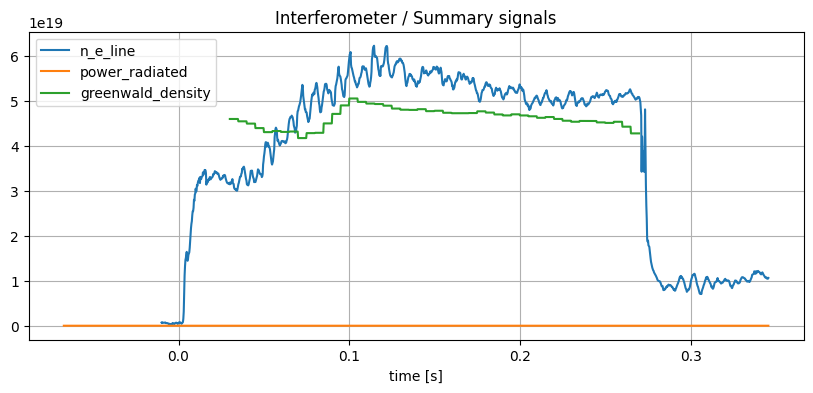

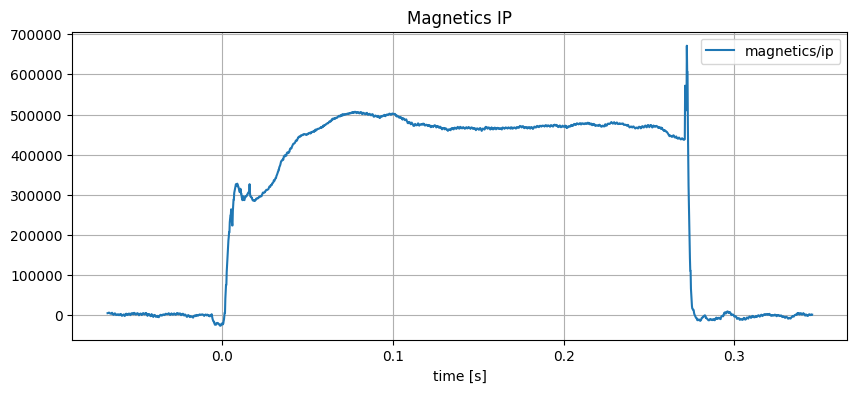

In [12]:
import matplotlib.pyplot as plt

t_interf = root["interferometer/time"][:]
t_mag = root["magnetics/time"][:]

plt.figure(figsize=(10,4))
plt.plot(t_interf, root["interferometer/n_e_line"][:], label="n_e_line")
plt.plot(t_interf, root["summary/power_radiated"][:], label="power_radiated")
plt.plot(t_interf, root["summary/greenwald_density"][:], label="greenwald_density")
plt.legend()
plt.xlabel("time [s]")
plt.title("Interferometer / Summary signals")
plt.grid(True)
plt.show()

plt.figure(figsize=(10,4))
plt.plot(t_mag, root["magnetics/ip"][:], label="magnetics/ip")
plt.legend()
plt.xlabel("time [s]")
plt.title("Magnetics IP")
plt.grid(True)
plt.show()

## 3. Identify a Common Valid Plasma Window

To analyze real plasma behavior, we first restrict attention to a time interval where the key diagnostic signals are simultaneously valid.

For the first shot, we use:

- interferometer line density `n_e_line`
- radiated power `power_radiated`
- Greenwald-density-related signal `greenwald_density`

A common valid window is defined as the region where all selected signals are finite at the same time. This gives a physically usable plasma segment for downstream fingerprint construction and event analysis.

This step is important because real experimental shots often contain:
- pre-plasma regions
- missing diagnostic values
- invalid or delayed derived quantities

So before defining any memory object, we must first isolate a jointly valid region of the shot.

In [13]:
n_e = root["interferometer/n_e_line"][:]
p_rad = root["summary/power_radiated"][:]
n_g = root["summary/greenwald_density"][:]

valid_mask = np.isfinite(n_e) & np.isfinite(p_rad) & np.isfinite(n_g)

valid_idx = np.where(valid_mask)[0]
print("Number of fully valid points:", len(valid_idx))

if len(valid_idx) > 0:
    start_idx = valid_idx[0]
    end_idx = valid_idx[-1]
    print("Valid window:")
    print("start index:", start_idx, "time:", t_interf[start_idx])
    print("end index:", end_idx, "time:", t_interf[end_idx])
else:
    print("No common fully valid window yet.")

Number of fully valid points: 960
Valid window:
start index: 389 time: 0.03004999494552621
end index: 1348 time: 0.2697999949455264


### Result: Common Valid Window for Shot 1

For Shot 1, we identified a jointly valid plasma window with:

- **960 valid time points**
- **start time:** approximately `0.03005 s`
- **end time:** approximately `0.26980 s`

This confirms that the shot contains a substantial physically usable segment for real-data analysis.

From this point onward, all fingerprint construction and candidate-event detection are performed inside this common valid window.

### Align Signals onto a Shared Time Base

The selected diagnostic signals do not all live on exactly the same native time grid. To construct a single plasma fingerprint at each time step, we align them onto a common time base.

For this first study:

- the interferometer time base is used as the reference grid
- plasma current \(I_p\), originally defined on the magnetics time base, is interpolated onto that grid
- only time points where all chosen signals are finite are retained

This produces a synchronized multi-signal plasma segment suitable for fingerprint construction and event comparison.

In [14]:
import numpy as np

# Interferometer/summary time base
t = root["interferometer/time"][:]

n_e = root["interferometer/n_e_line"][:]
p_rad = root["summary/power_radiated"][:]
n_g = root["summary/greenwald_density"][:]

# Magnetics time base
t_ip = root["magnetics/time"][:]
ip = root["magnetics/ip"][:]

# Interpolate IP onto interferometer time base
ip_interp = np.interp(t, t_ip, ip)

# Valid mask
valid_mask = np.isfinite(n_e) & np.isfinite(p_rad) & np.isfinite(n_g) & np.isfinite(ip_interp)

t_valid = t[valid_mask]
n_e_valid = n_e[valid_mask]
p_rad_valid = p_rad[valid_mask]
n_g_valid = n_g[valid_mask]
ip_valid = ip_interp[valid_mask]

print("Valid points:", len(t_valid))
print("Valid time window:", t_valid[0], "to", t_valid[-1])

Valid points: 960
Valid time window: 0.03004999494552621 to 0.2697999949455264


### Result: Synchronized Valid Segment

After aligning \(I_p\) to the interferometer time base and applying the common validity mask, the usable segment remains:

- **960 valid points**
- **time window:** `0.03005 s` to `0.26980 s`

This confirms that the chosen signals can be analyzed together as a single synchronized plasma trajectory.

### Build the Plasma Fingerprint Matrix

We now represent each time point in the synchronized valid window by a compact plasma fingerprint:

\[
x(t) = [I_p(t),\ n_e^{line}(t),\ P_{rad}(t),\ n_G(t)]
\]

where:

- \(I_p\) is plasma current
- \(n_e^{line}\) is line density
- \(P_{rad}\) is radiated power
- \(n_G\) is the Greenwald-density-related signal

Each signal is normalized so that the comparison focuses on relative plasma behavior rather than raw unit scale.

In [15]:
def zscore(x):
    return (x - np.nanmean(x)) / (np.nanstd(x) + 1e-12)

X = np.column_stack([
    zscore(ip_valid),
    zscore(n_e_valid),
    zscore(p_rad_valid),
    zscore(n_g_valid),
])

print("Fingerprint matrix shape:", X.shape)
print("First row:", X[0])

Fingerprint matrix shape: (960, 4)
First row: [-5.45957506 -2.77444151 -0.27904511 -0.123895  ]


In [16]:
# Estimate derivative of interpolated IP on valid window
dt = np.gradient(t_valid)
dip_dt = np.gradient(ip_valid, t_valid)

# failure time = strongest downward slope
failure_idx = np.argmin(dip_dt)
t_f = t_valid[failure_idx]

print("Candidate failure index:", failure_idx)
print("Candidate failure time:", t_f)
print("dIp/dt at failure:", dip_dt[failure_idx])

Candidate failure index: 312
Candidate failure time: 0.10804999494552628
dIp/dt at failure: -10635281.249893308


### Result: Candidate Event for Shot 1

For Shot 1, the proxy candidate event occurs at:

- **index:** `312`
- **time:** approximately `0.10805 s`

At this time, the plasma current shows its strongest negative local slope within the synchronized valid window:

\[
\frac{dI_p}{dt} \approx -1.06 \times 10^7
\]

This event is used as the first anchor point for defining a real-data plasma memory object.

In [17]:
delta = 20  # choose a small backward window in samples

prev_idx = max(0, failure_idx - delta)

x_fail = X[failure_idx]
x_prev = X[prev_idx]

d_approach = x_fail - x_prev
norm = np.linalg.norm(d_approach)

if norm > 0:
    d_approach = d_approach / norm

print("Failure time:", t_valid[failure_idx])
print("Previous time:", t_valid[prev_idx])
print("x_fail:", x_fail)
print("x_prev:", x_prev)
print("Approach direction:", d_approach)

Failure time: 0.10804999494552628
Previous time: 0.10304999494552627
x_fail: [0.63182518 1.03151881 0.41445133 1.71056715]
x_prev: [1.06367767 0.64375224 0.86750517 2.07656525]
Approach direction: [-0.52521726  0.47160015 -0.55100226 -0.44512542]


### Result: First Real Plasma Memory Object

Using the candidate event time and a short backward window of 20 samples, we extract:

- the **event fingerprint** \(x_{\text{fail}}\)
- the **previous fingerprint** \(x_{\text{prev}}\)
- the normalized **approach direction** \(d_{\text{approach}}\)

For Shot 1:

\[
x_{\text{fail}} = [0.6318,\ 1.0315,\ 0.4145,\ 1.7106]
\]

\[
x_{\text{prev}} = [1.0637,\ 0.6438,\ 0.8675,\ 2.0766]
\]

\[
d_{\text{approach}} = [-0.5252,\ 0.4716,\ -0.5510,\ -0.4451]
\]

This is the first real-data plasma memory object in the notebook. It shows that the event is not defined only by a single state, but by a short approach trajectory in multi-signal feature space.

### Visualize the Candidate Event

The plot below marks:

- the **candidate event time** (red dashed line)
- the **start of the approach window** (orange dashed line)

This makes the selected event anchor visually interpretable in the plasma-current trajectory.

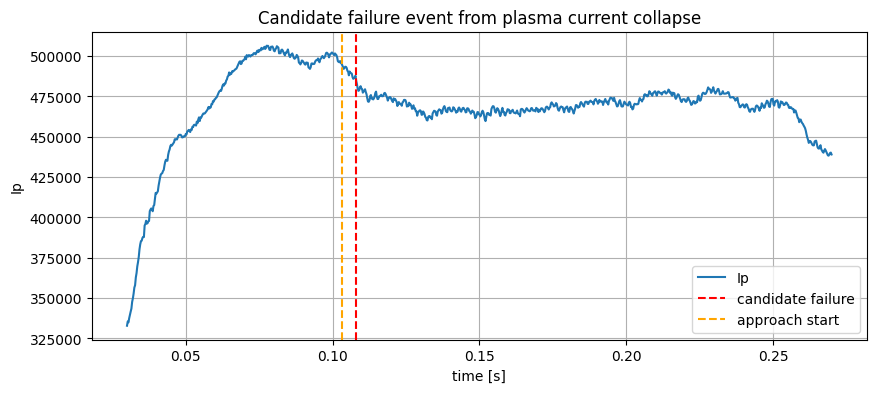

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(t_valid, ip_valid, label="Ip")
plt.axvline(t_valid[failure_idx], color="red", linestyle="--", label="candidate failure")
plt.axvline(t_valid[prev_idx], color="orange", linestyle="--", label="approach start")
plt.xlabel("time [s]")
plt.ylabel("Ip")
plt.title("Candidate failure event from plasma current collapse")
plt.legend()
plt.grid(True)
plt.show()

## 7. Shot 2: Event Fingerprint and Approach Direction

We now repeat the same pipeline for a second real shot.

For Shot 2, we:
- extract the shot archive
- build the synchronized valid plasma segment
- identify a proxy candidate event using the strongest negative \(dI_p/dt\)
- extract the event fingerprint and normalized approach direction

This gives us a second real plasma memory object for cross-shot comparison.

In [19]:
SHOT_ID = "11767"
INNER_ZIP = f"stage_upload/{SHOT_ID}.zarr.zip"
EXTRACT_DIR = f"tmp_{SHOT_ID}"

In [20]:
import zipfile
import io
import os
import shutil

if os.path.exists(EXTRACT_DIR):
    shutil.rmtree(EXTRACT_DIR)
os.makedirs(EXTRACT_DIR, exist_ok=True)

with zipfile.ZipFile(OUTER_ZIP, "r") as outer:
    inner_bytes = outer.read(INNER_ZIP)

with zipfile.ZipFile(io.BytesIO(inner_bytes), "r") as inner:
    inner.extractall(EXTRACT_DIR)

print("Extracted:", SHOT_ID)

Extracted: 11767


In [21]:
import zarr

base2 = os.path.join(EXTRACT_DIR, f"{SHOT_ID}.zarr")
root2 = zarr.open(base2, mode="r")
print(os.listdir(base2))

['.zgroup', '.zmetadata', 'equilibrium', 'gas_injection', 'interferometer', 'magnetics', 'pf_active', 'pulse_schedule', 'spectrometer_visible', 'summary']


In [22]:
t2 = root2["interferometer/time"][:]

n_e2 = root2["interferometer/n_e_line"][:]
p_rad2 = root2["summary/power_radiated"][:]
n_g2 = root2["summary/greenwald_density"][:]

t_ip2 = root2["magnetics/time"][:]
ip2 = root2["magnetics/ip"][:]

ip_interp2 = np.interp(t2, t_ip2, ip2)

In [23]:
valid_mask2 = (
    np.isfinite(n_e2) &
    np.isfinite(p_rad2) &
    np.isfinite(n_g2) &
    np.isfinite(ip_interp2)
)

t_valid2 = t2[valid_mask2]
n_e_valid2 = n_e2[valid_mask2]
p_rad_valid2 = p_rad2[valid_mask2]
n_g_valid2 = n_g2[valid_mask2]
ip_valid2 = ip_interp2[valid_mask2]

print("Valid points:", len(t_valid2))
if len(t_valid2) > 0:
    print("Valid window:", t_valid2[0], "to", t_valid2[-1])

Valid points: 860
Valid window: 0.03004999494552621 to 0.2447999949455264


In [24]:
X2 = np.column_stack([
    zscore(ip_valid2),
    zscore(n_e_valid2),
    zscore(p_rad_valid2),
    zscore(n_g_valid2),
])

print("Fingerprint matrix shape:", X2.shape)
print("First row:", X2[0])

Fingerprint matrix shape: (860, 4)
First row: [-4.92242203 -2.47038132 -0.11705361 -0.4805078 ]


In [25]:
dip_dt2 = np.gradient(ip_valid2, t_valid2)

failure_idx2 = np.argmin(dip_dt2)
t_f2 = t_valid2[failure_idx2]

print("Candidate failure index:", failure_idx2)
print("Candidate failure time:", t_f2)
print("dIp/dt at failure:", dip_dt2[failure_idx2])

Candidate failure index: 273
Candidate failure time: 0.09829999494552627
dIp/dt at failure: -14212046.874943137


In [26]:
delta = 20
prev_idx2 = max(0, failure_idx2 - delta)

x_fail_2 = X2[failure_idx2]
x_prev_2 = X2[prev_idx2]

d_approach_2 = x_fail_2 - x_prev_2
norm2 = np.linalg.norm(d_approach_2)
if norm2 > 0:
    d_approach_2 = d_approach_2 / norm2

print("Failure time:", t_valid2[failure_idx2])
print("Previous time:", t_valid2[prev_idx2])
print("x_fail_2:", x_fail_2)
print("x_prev_2:", x_prev_2)
print("d_approach_2:", d_approach_2)

Failure time: 0.09829999494552627
Previous time: 0.09329999494552627
x_fail_2: [ 1.78812772 -0.44247447  1.13477453  0.55895312]
x_prev_2: [ 1.20028095  1.25663889  0.08058562 -0.09995573]
d_approach_2: [ 0.26893041 -0.77731695  0.48227442  0.30144017]


### Result: Shot 2 Memory Object

For Shot 2, we extract a second real-data plasma memory object consisting of:

- the event fingerprint \(x_{\text{fail},2}\)
- the previous fingerprint \(x_{\text{prev},2}\)
- the normalized approach direction \(d_{\text{approach},2}\)

This object is used later in the cross-shot direction-aware comparison.

### Visualize the Candidate Event for Shot 2

The plot below shows the selected proxy event and the short approach window used to define the Shot 2 memory object.

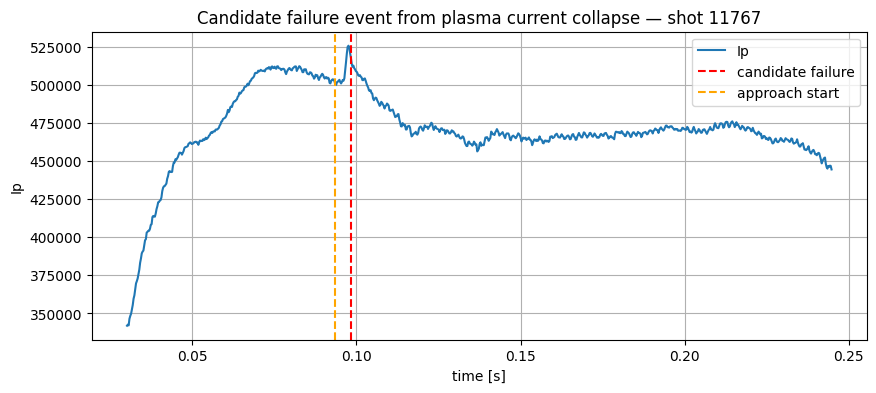

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(t_valid2, ip_valid2, label="Ip")
plt.axvline(t_valid2[failure_idx2], color="red", linestyle="--", label="candidate failure")
plt.axvline(t_valid2[prev_idx2], color="orange", linestyle="--", label="approach start")
plt.xlabel("time [s]")
plt.ylabel("Ip")
plt.title(f"Candidate failure event from plasma current collapse — shot {SHOT_ID}")
plt.legend()
plt.grid(True)
plt.show()

### Visualize the Candidate Event for Shot 2

The plot below shows the selected proxy event and the short approach window used to define the Shot 2 memory object.

In [28]:
x_fail_1 = np.array([0.63182518, 1.03151881, 0.41445133, 1.71056715])
d_approach_1 = np.array([-0.52521726, 0.47160015, -0.55100226, -0.44512542])

sim_x = np.dot(x_fail_1, x_fail_2) / (
    np.linalg.norm(x_fail_1) * np.linalg.norm(x_fail_2) + 1e-12
)

sim_d = np.dot(d_approach_1, d_approach_2)

print("Fingerprint cosine similarity:", sim_x)
print("Approach-direction similarity:", sim_d)

Fingerprint cosine similarity: 0.439997929647944
Approach-direction similarity: -0.9077426622261929


Two real-shot candidate events showed only moderate fingerprint similarity (≈0.44) but strongly opposing approach directions (≈−0.91). This indicates that event-state resemblance alone is insufficient for memory matching; trajectory direction is necessary to distinguish whether two plasma segments are evolving toward failure in a genuinely similar way.

In [29]:
alpha = 0.5
combined_score = alpha * sim_x + (1 - alpha) * max(0, sim_d)
print("Combined memory-match score:", combined_score)

Combined memory-match score: 0.219998964823972


Combined memory-match score = 0.22.
Although the two candidate events show moderate state similarity, their approach directions are strongly opposed, so the combined memory score remains low. This supports direction-aware failure memory rather than state-only matching.

## 8. Shot 3: Event Fingerprint and Approach Direction

We repeat the same event-extraction pipeline for a third real shot, producing a third plasma memory object for pairwise comparison.

In [30]:
SHOT_ID = "11768"
INNER_ZIP = f"stage_upload/{SHOT_ID}.zarr.zip"
EXTRACT_DIR = f"tmp_{SHOT_ID}"

In [31]:
import zipfile
import io
import os
import shutil

if os.path.exists(EXTRACT_DIR):
    shutil.rmtree(EXTRACT_DIR)
os.makedirs(EXTRACT_DIR, exist_ok=True)

with zipfile.ZipFile(OUTER_ZIP, "r") as outer:
    inner_bytes = outer.read(INNER_ZIP)

with zipfile.ZipFile(io.BytesIO(inner_bytes), "r") as inner:
    inner.extractall(EXTRACT_DIR)

print("Extracted:", SHOT_ID)

Extracted: 11768


In [32]:
import zarr

base3 = os.path.join(EXTRACT_DIR, f"{SHOT_ID}.zarr")
root3 = zarr.open(base3, mode="r")
print(os.listdir(base3))

['.zgroup', '.zmetadata', 'equilibrium', 'gas_injection', 'interferometer', 'magnetics', 'pf_active', 'pulse_schedule', 'soft_x_rays', 'spectrometer_visible', 'summary']


In [33]:
t3 = root3["interferometer/time"][:]

n_e3 = root3["interferometer/n_e_line"][:]
p_rad3 = root3["summary/power_radiated"][:]
n_g3 = root3["summary/greenwald_density"][:]

t_ip3 = root3["magnetics/time"][:]
ip3 = root3["magnetics/ip"][:]

ip_interp3 = np.interp(t3, t_ip3, ip3)

In [34]:
valid_mask3 = (
    np.isfinite(n_e3) &
    np.isfinite(p_rad3) &
    np.isfinite(n_g3) &
    np.isfinite(ip_interp3)
)

t_valid3 = t3[valid_mask3]
n_e_valid3 = n_e3[valid_mask3]
p_rad_valid3 = p_rad3[valid_mask3]
n_g_valid3 = n_g3[valid_mask3]
ip_valid3 = ip_interp3[valid_mask3]

print("Valid points:", len(t_valid3))
if len(t_valid3) > 0:
    print("Valid window:", t_valid3[0], "to", t_valid3[-1])

Valid points: 960
Valid window: 0.03004999494552621 to 0.2697999949455264


In [35]:
X3 = np.column_stack([
    zscore(ip_valid3),
    zscore(n_e_valid3),
    zscore(p_rad_valid3),
    zscore(n_g_valid3),
])

print("Fingerprint matrix shape:", X3.shape)
print("First row:", X3[0])

Fingerprint matrix shape: (960, 4)
First row: [-5.40581717 -2.83868502  0.86191135 -0.69620213]


In [36]:
dip_dt3 = np.gradient(ip_valid3, t_valid3)

failure_idx3 = np.argmin(dip_dt3)
t_f3 = t_valid3[failure_idx3]

print("Candidate failure index:", failure_idx3)
print("Candidate failure time:", t_f3)
print("dIp/dt at failure:", dip_dt3[failure_idx3])

Candidate failure index: 352
Candidate failure time: 0.11804999494552629
dIp/dt at failure: -9109687.499968529


In [37]:
delta = 20
prev_idx3 = max(0, failure_idx3 - delta)

x_fail_3 = X3[failure_idx3]
x_prev_3 = X3[prev_idx3]

d_approach_3 = x_fail_3 - x_prev_3
norm3 = np.linalg.norm(d_approach_3)
if norm3 > 0:
    d_approach_3 = d_approach_3 / norm3

print("Failure time:", t_valid3[failure_idx3])
print("Previous time:", t_valid3[prev_idx3])
print("x_fail_3:", x_fail_3)
print("x_prev_3:", x_prev_3)
print("d_approach_3:", d_approach_3)

Failure time: 0.11804999494552629
Previous time: 0.11304999494552628
x_fail_3: [ 0.20658926  1.06018897 -0.79495536  1.49111102]
x_prev_3: [ 0.38770753  0.90832355 -1.17511781  1.4580683 ]
d_approach_3: [-0.40350031  0.33832999  0.84693646  0.0736135 ]


### Visualize the Candidate Event for Shot 3

The plot below marks the Shot 3 proxy event and the corresponding short approach window used to construct the memory object.

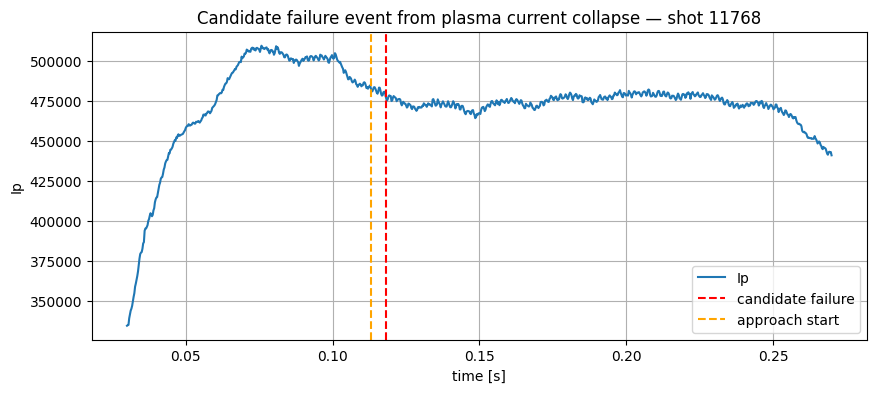

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(t_valid3, ip_valid3, label="Ip")
plt.axvline(t_valid3[failure_idx3], color="red", linestyle="--", label="candidate failure")
plt.axvline(t_valid3[prev_idx3], color="orange", linestyle="--", label="approach start")
plt.xlabel("time [s]")
plt.ylabel("Ip")
plt.title(f"Candidate failure event from plasma current collapse — shot {SHOT_ID}")
plt.legend()
plt.grid(True)
plt.show()

In [39]:
# Save shot 3 objects
x_fail_3 = np.array([0.20658926, 1.06018897, -0.79495536, 1.49111102])
d_approach_3 = np.array([-0.40350031, 0.33832999, 0.84693646, 0.0736135 ])

In [40]:
def cosine_sim(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12)

def combined_score(xa, xb, da, db, alpha=0.5):
    sim_x = cosine_sim(xa, xb)
    sim_d = np.dot(da, db)
    score = alpha * sim_x + (1 - alpha) * max(0, sim_d)
    return sim_x, sim_d, score

In [41]:
pairs = [
    ("S1 vs S2", x_fail_1, x_fail_2, d_approach_1, d_approach_2),
    ("S1 vs S3", x_fail_1, x_fail_3, d_approach_1, d_approach_3),
    ("S2 vs S3", x_fail_2, x_fail_3, d_approach_2, d_approach_3),
]

results = []

for name, xa, xb, da, db in pairs:
    sim_x, sim_d, score = combined_score(xa, xb, da, db, alpha=0.5)
    results.append({
        "pair": name,
        "state_similarity": sim_x,
        "direction_similarity": sim_d,
        "combined_score": score,
    })

results

[{'pair': 'S1 vs S2',
  'state_similarity': np.float64(0.439997929647944),
  'direction_similarity': np.float64(-0.9077426622261929),
  'combined_score': np.float64(0.219998964823972)},
 {'pair': 'S1 vs S3',
  'state_similarity': np.float64(0.804400738111487),
  'direction_similarity': np.float64(-0.12794934238072048),
  'combined_score': np.float64(0.4022003690557435)},
 {'pair': 'S2 vs S3',
  'state_similarity': np.float64(-0.037562069002334636),
  'direction_similarity': np.float64(0.05914271438518409),
  'combined_score': np.float64(0.010790322691424728)}]

In [42]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [43]:
import pandas as pd

df_results = pd.DataFrame(results)
df_results

,pair,state_similarity,direction_similarity,combined_score
0,S1 vs S2,0.439998,-0.907743,0.219999
1,S1 vs S3,0.804401,-0.127949,0.402200
2,S2 vs S3,-0.037562,0.059143,0.010790


In [44]:
def label_match(row):
    sim_x = float(row["state_similarity"])
    sim_d = float(row["direction_similarity"])
    score = float(row["combined_score"])

    if sim_x > 0.3 and sim_d < -0.5:
        return "misleading state-only match"
    elif score > 0.5 and sim_d > 0:
        return "strong match"
    elif score > 0.2:
        return "partial / uncertain"
    else:
        return "reject"

df_results["label"] = df_results.apply(label_match, axis=1)
df_results

,pair,state_similarity,direction_similarity,combined_score,label
0,S1 vs S2,0.439998,-0.907743,0.219999,misleading state-only match
1,S1 vs S3,0.804401,-0.127949,0.402200,partial / uncertain
2,S2 vs S3,-0.037562,0.059143,0.010790,reject


Across three real plasma shots, the combined memory score separates misleading, partial, and unrelated candidate event pairs. This supports direction-aware failure memory rather than state-only event matching.

In [45]:
import os
import json

os.makedirs("demo", exist_ok=True)

shot_map = {
    "S1": "11766",
    "S2": "11767",
    "S3": "11768"
}

def make_confidence(row):
    sim_d = row["direction_similarity"]
    score = row["combined_score"]

    if sim_d < -0.5:
        return "high"
    elif score > 0.5:
        return "high"
    elif score > 0.2:
        return "medium"
    else:
        return "medium"

def make_verification_note(row):
    label = row["label"]

    if label == "misleading state-only match":
        return "moderate or strong state resemblance is overridden by strongly opposing approach direction"
    elif label == "partial / uncertain":
        return "state resemblance exists, but direction compatibility is not strong enough for a confident reusable match"
    elif label == "strong match":
        return "state and direction are both sufficiently compatible"
    else:
        return "insufficient similarity for a reusable failure-memory match"

def make_next_check(row):
    label = row["label"]

    if label == "misleading state-only match":
        return "review additional magnetic fluctuation channels before treating this as a reusable prior-risk case"
    elif label == "partial / uncertain":
        return "inspect nearby temporal signal evolution and auxiliary diagnostics before reuse"
    elif label == "strong match":
        return "compare additional supporting diagnostics to confirm the match"
    else:
        return "search for alternative prior cases with closer trajectory compatibility"

export_cases = []

for _, row in df_results.iterrows():
    left, right = row["pair"].split(" vs ")
    current_shot = shot_map[left.strip()]
    reference_shot = shot_map[right.strip()]

    export_cases.append({
        "current_shot": current_shot,
        "reference_shot": reference_shot,
        "state_similarity": round(float(row["state_similarity"]), 4),
        "direction_similarity": round(float(row["direction_similarity"]), 4),
        "combined_score": round(float(row["combined_score"]), 4),
        "final_label": row["label"],
        "confidence": make_confidence(row),
        "verification_note": make_verification_note(row),
        "next_check": make_next_check(row)
    })

with open("demo/real_cases.json", "w") as f:
    json.dump(export_cases, f, indent=2)

print("Saved:", "demo/real_cases.json")
export_cases

Saved: demo/real_cases.json


[{'current_shot': '11766',
  'reference_shot': '11767',
  'state_similarity': 0.44,
  'direction_similarity': -0.9077,
  'combined_score': 0.22,
  'final_label': 'misleading state-only match',
  'confidence': 'high',
  'verification_note': 'moderate or strong state resemblance is overridden by strongly opposing approach direction',
  'next_check': 'review additional magnetic fluctuation channels before treating this as a reusable prior-risk case'},
 {'current_shot': '11766',
  'reference_shot': '11768',
  'state_similarity': 0.8044,
  'direction_similarity': -0.1279,
  'combined_score': 0.4022,
  'final_label': 'partial / uncertain',
  'confidence': 'medium',
  'verification_note': 'state resemblance exists, but direction compatibility is not strong enough for a confident reusable match',
  'next_check': 'inspect nearby temporal signal evolution and auxiliary diagnostics before reuse'},
 {'current_shot': '11767',
  'reference_shot': '11768',
  'state_similarity': -0.0376,
  'direction_